# Data transformations

In this document we will examine how the models transform the data, before proceeding to the multiclass classification task. The models that under evaluation are a Transformer and a LSTM. For the data visualization, t-SNE and UMAP will be used followed by their results comparison.

## Dataset and tools loading
Loading the required libraries and datasets needed to train and test the models. Models are trained on 145621 samples and tested on 5282 samples. Thus, we have 5282 points on the t-SNE and UMAP plots that will be shown later.

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torcheval.metrics import MulticlassAccuracy
import sys
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils import dataset_utils
from utils import train_test_utils as ttutils
from utils.models import MyTransformerModel, MyLSTMClassifier, MyCNNModel

from IPython.utils.io import capture_output

print(sys.path)

def load_config(file_path):
    with open(file_path, "r") as file:
        json_data = json.load(file)
        config = json_data["config"]
    return config

dataset_file = "/mnt/btrfs/datasets/cybersecurity/multiclass/extracted/cybersecurity-unified-multiclass-malicious.csv"
dataset_name = os.path.basename(dataset_file).split(".")[0]
lstm_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}.pt")
lstm_removed_sep_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_sep_removed.pt")
lstm_removed_uni_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_uni_removed.pt")
transformer_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}.pt")
transformer_sep_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_sep_removed.pt")
transformer_uni_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_uni_removed.pt")
cnn_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_cnn_{dataset_name}.pt")
cnn_sep_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_cnn_{dataset_name}_sep_removed.pt")

rows_limit = 250e+3
chunk_size = 3e+6
DEVICE = ttutils.get_device()
TRANSFORMER_EPOCHS = 45
LSTM_EPOCHS = 10
CNN_EPOCHS = 40

with capture_output():
    csv_dataset = dataset_utils.CSVDataset(dataset_file, "Label", columns_to_drop=["Timestamp"], chunk_size=chunk_size)
    csv_dataset.load(rows_limit=rows_limit)

features, category_map, n_classes = csv_dataset.features, csv_dataset.categories, csv_dataset.n_classes
dataset_df = pd.DataFrame(csv_dataset.X.numpy(), columns=csv_dataset.features, dtype="float32")
dataset_df["Label"] = csv_dataset.y.numpy()
y = csv_dataset.y
X = csv_dataset.X
del csv_dataset

dataset_lstm_removed_df = dataset_df.drop(columns=["Fwd Seg Size Min", "Label"])
dataset_transformer_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Idle Mean", "Idle Min", "Idle Max", "Label"])
dataset_cnn_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Idle Mean", "Idle Min", "Idle Max", "Idle Std", "Label"])
dataset_unified_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Fwd Seg Size Min", "Init Bwd Win Byts",
                                                        "Idle Mean", "Idle Min", "Idle Max", "Label"])

X_lstm_removed = torch.from_numpy(dataset_lstm_removed_df.to_numpy(dtype="float32"))
X_transformer_removed = torch.from_numpy(dataset_transformer_removed_df.to_numpy(dtype="float32"))
X_cnn_removed = torch.from_numpy(dataset_cnn_removed_df.to_numpy(dtype="float32"))
X_unified_removed = torch.from_numpy(dataset_unified_removed_df.to_numpy(dtype="float32"))
del dataset_lstm_removed_df, dataset_transformer_removed_df, dataset_cnn_removed_df, dataset_unified_removed_df

print(category_map)
print(X.shape, X_lstm_removed.shape, X_transformer_removed.shape, X_cnn_removed.shape, X_unified_removed.shape)

dataset = TensorDataset(X,y)
dataset_lstm_removed = TensorDataset(X_lstm_removed, y)
dataset_transformer_removed = TensorDataset(X_transformer_removed, y)
dataset_cnn_removed = TensorDataset(X_cnn_removed, y)
dataset_unified_removed = TensorDataset(X_unified_removed, y)

del X, X_lstm_removed, X_transformer_removed, X_cnn_removed, X_unified_removed, y
dataset_df


['/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages/ray/thirdparty_files', '/home/sbaltsas/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python313.zip', '/home/sbaltsas/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13', '/home/sbaltsas/.local/share/uv/python/cpython-3.13-linux-x86_64-gnu/lib/python3.13/lib-dynload', '', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages', '/tmp/tmpi9o9h6yg', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis']
CUDA available! GPU device name is: NVIDIA GeForce RTX 4060
{0: 'Scanner', 1: 'DoS', 2: 'Botnet', 3: 'Brute force', 4: 'Exploit', 5: 'Generic', 6: 'MITM', 7: 'Infection'}
torch.Size([134136, 81]) torch.Size([134136, 80]) torch.Size([134136, 76]) torch.Size([134136, 75]) torch.Size([134136, 74])


,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3.232261e+09,17576.0,2.691704e+09,8081.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,3.232261e+09,17576.0,2.189254e+09,8081.0,6.0,5.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3.232261e+09,17576.0,1.221897e+09,8081.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3.232261e+09,17576.0,3.253846e+09,8081.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,3.232261e+09,18088.0,3.566601e+09,8080.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134131,2.939007e+09,46976.0,2.511044e+09,80.0,6.0,30563.0,0.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
134132,2.939007e+09,54298.0,2.511044e+09,80.0,6.0,106867.0,0.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
134133,2.939007e+09,60815.0,2.511044e+09,8080.0,6.0,67754.0,0.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
134134,2.939007e+09,55455.0,2.511044e+09,80.0,6.0,152943.0,0.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


## Training models and data transformation

In order to visualize the data transformation of the best model, we need to train the model first on the 90% of the dataset. The rest 10% will be used for visualization needs.

### Training
#### Transformer

In [3]:
transformer_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_transformer", "best_config_multiclass.json")
config = load_config(transformer_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
transformer_hyperparameters = config
enc_embed_dim = config["enc_embedding_dim"]
transformer_model = MyTransformerModel(dataset.tensors[0].shape[1], n_classes, **transformer_hyperparameters)

transformer_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_transformer", "improved_removed_features_best_config.json")
config = load_config(transformer_removed_config_file)
learning_removed_rate = config.pop("lr")
batch_removed_size = config.pop("batch_size")
transformer_removed_hyperparameters = config
enc_embed_dim_removed = config["enc_embedding_dim"]
transformer_sep_removed_model = MyTransformerModel(dataset_transformer_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)
transformer_uni_removed_model = MyTransformerModel(dataset_unified_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)

# training transformer with all network specific features included
train_data, test_data = random_split(dataset, [0.965, 0.035])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_model.to(DEVICE)
ttutils.train_model(transformer_model, transformer_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=TRANSFORMER_EPOCHS)

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages/torcheval/metrics/functional/classification/accuracy.py:275: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:232.)
  num_correct = mask.new_zeros(num_classes).scatter_(0, target, mask, reduce="add")


Epoch 1/45. Average train accuracy: 55.039%, average loss: 1.11342, current loss: 0.92293.
Saved model!
Epoch 2/45. Average train accuracy: 61.561%, average loss: 0.91003, current loss: 1.47929.
Saved model!
Epoch 3/45. Average train accuracy: 62.886%, average loss: 0.87255, current loss: 0.59128.
Saved model!
Epoch 4/45. Average train accuracy: 64.649%, average loss: 0.83743, current loss: 0.66497.
Saved model!
Epoch 5/45. Average train accuracy: 66.087%, average loss: 0.80449, current loss: 0.62445.
Saved model!
Epoch 6/45. Average train accuracy: 67.166%, average loss: 0.77178, current loss: 0.29206.
Saved model!
Epoch 7/45. Average train accuracy: 68.154%, average loss: 0.73846, current loss: 0.18616.
Saved model!
Epoch 8/45. Average train accuracy: 69.059%, average loss: 0.71865, current loss: 1.14988.
Saved model!
Epoch 9/45. Average train accuracy: 69.303%, average loss: 0.70528, current loss: 0.31751.
Saved model!
Epoch 10/45. Average train accuracy: 69.714%, average loss: 0.69

In [4]:
# training transformer with separate removed network specific features
train_sep_removed_data, test_sep_removed_data = random_split(dataset_transformer_removed, [0.965, 0.035])
train_loader = DataLoader(train_sep_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_sep_removed_model.to(DEVICE)
ttutils.train_model(transformer_sep_removed_model, transformer_sep_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 86.776%, average loss: 0.38837, current loss: 0.16456.
Saved model!
Epoch 2/45. Average train accuracy: 95.858%, average loss: 0.15508, current loss: 0.08485.
Saved model!
Epoch 3/45. Average train accuracy: 96.367%, average loss: 0.13515, current loss: 0.15938.
Saved model!
Epoch 4/45. Average train accuracy: 96.444%, average loss: 0.12999, current loss: 0.19450.
Saved model!
Epoch 5/45. Average train accuracy: 96.960%, average loss: 0.11132, current loss: 0.18596.
Saved model!
Epoch 6/45. Average train accuracy: 96.949%, average loss: 0.11409, current loss: 0.04673.
Epoch 7/45. Average train accuracy: 97.261%, average loss: 0.10132, current loss: 0.09542.
Saved model!
Epoch 8/45. Average train accuracy: 96.996%, average loss: 0.11164, current loss: 0.06369.
Epoch 9/45. Average train accuracy: 97.297%, average loss: 0.09826, current loss: 0.07337.
Saved model!
Epoch 10/45. Average train accuracy: 96.914%, average loss: 0.11137, current loss: 0.06076

In [5]:
# training transformer with unified removed network specific features
train_uni_removed_data, test_uni_removed_data = random_split(dataset_unified_removed, [0.965, 0.035])
train_loader = DataLoader(train_uni_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_uni_removed_model.to(DEVICE)
ttutils.train_model(transformer_uni_removed_model, transformer_uni_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 87.891%, average loss: 0.37120, current loss: 0.18404.
Saved model!
Epoch 2/45. Average train accuracy: 95.898%, average loss: 0.15691, current loss: 0.15424.
Saved model!
Epoch 3/45. Average train accuracy: 95.925%, average loss: 0.15562, current loss: 0.26608.
Saved model!
Epoch 4/45. Average train accuracy: 96.789%, average loss: 0.11958, current loss: 0.09667.
Saved model!
Epoch 5/45. Average train accuracy: 96.499%, average loss: 0.12953, current loss: 0.06437.
Epoch 6/45. Average train accuracy: 96.953%, average loss: 0.11144, current loss: 0.16651.
Saved model!
Epoch 7/45. Average train accuracy: 96.815%, average loss: 0.11608, current loss: 0.11967.
Epoch 8/45. Average train accuracy: 96.935%, average loss: 0.11092, current loss: 0.06720.
Saved model!
Epoch 9/45. Average train accuracy: 97.221%, average loss: 0.10046, current loss: 0.20731.
Saved model!
Epoch 10/45. Average train accuracy: 96.808%, average loss: 0.11905, current loss: 0.12834

### Inference and data transformation
#### Transformer
**All network specific features included**

KL divergence: 0.2581614851951599


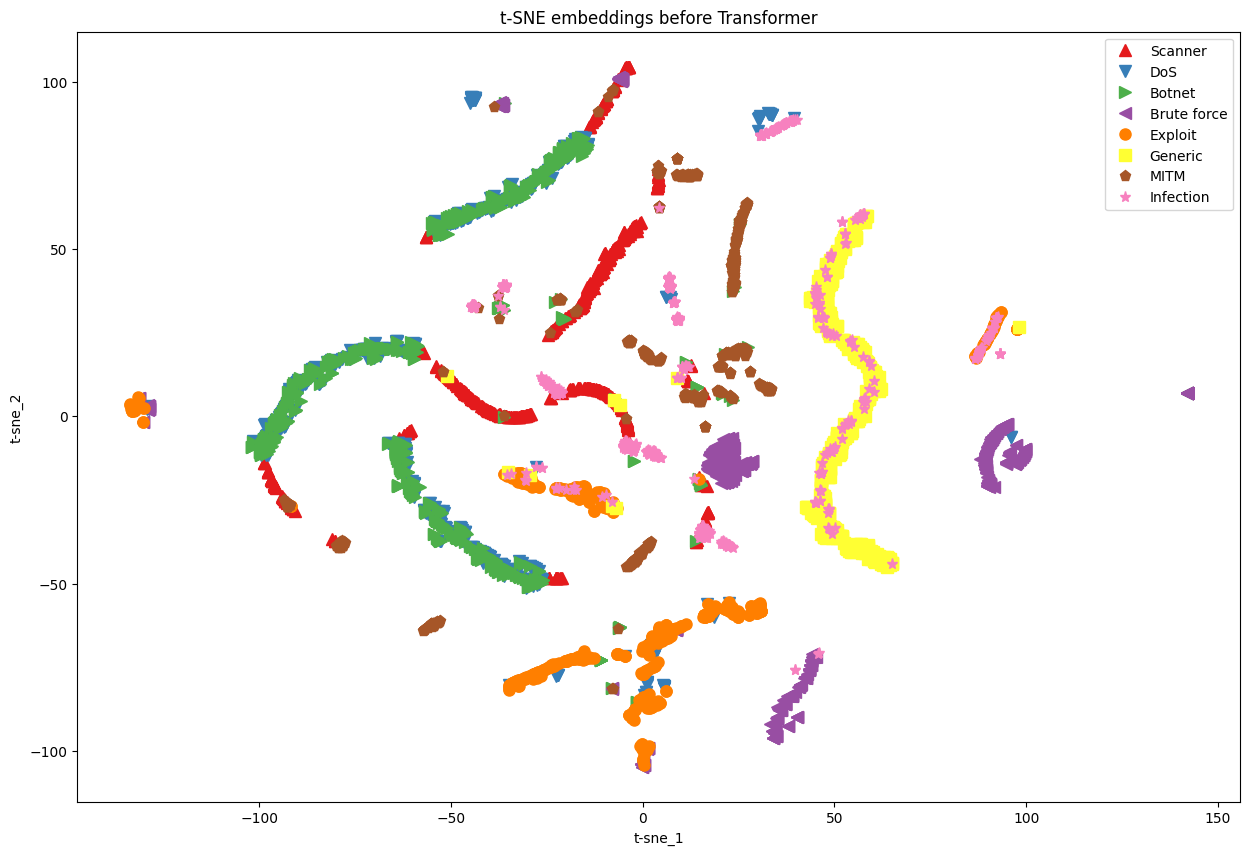

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


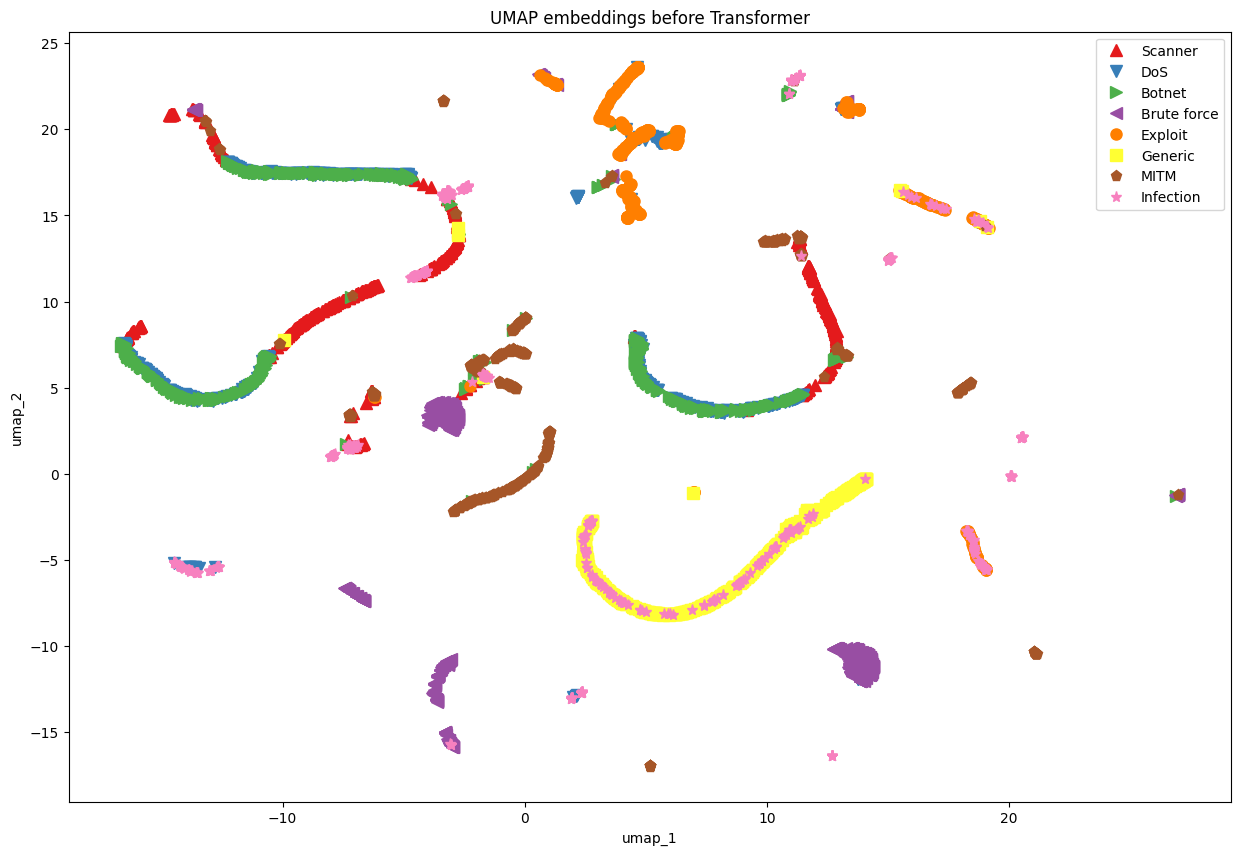

In [6]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
tsne_reducer = TSNE(n_components=2, perplexity=25, method="barnes_hut", n_jobs=-1, max_iter=2000)

X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)

def plot_embedding(embedding, y_test, reducer_type="umap", title="plot"):
    import matplotlib as mpl
    colors = mpl.colormaps["Set1"].colors[:n_classes]
    markers = ("^", "v", ">", "<", "o", "s", "p", "*", "D")
    df = pd.DataFrame(embedding, columns=[f"{reducer_type}_1", f"{reducer_type}_2"])
    df["Label"] = y_test
    df.shape
    groups = df.groupby("Label")
    fig = plt.figure(figsize=((15,10)))
    ax = fig.add_subplot()
    for i, group in enumerate(groups):
        name, group_data = group
        ax.plot(group_data[f"{reducer_type}_1"], group_data[f"{reducer_type}_2"], marker=markers[i], 
                color=colors[i], linestyle='', label=category_map[name], markersize=8)
    ax.legend()
    ax.set_xlabel(f"{reducer_type}_1")
    ax.set_ylabel(f"{reducer_type}_2")
    ax.set_title(title)
    plt.show()

plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")


81
KL divergence: 0.34295910596847534


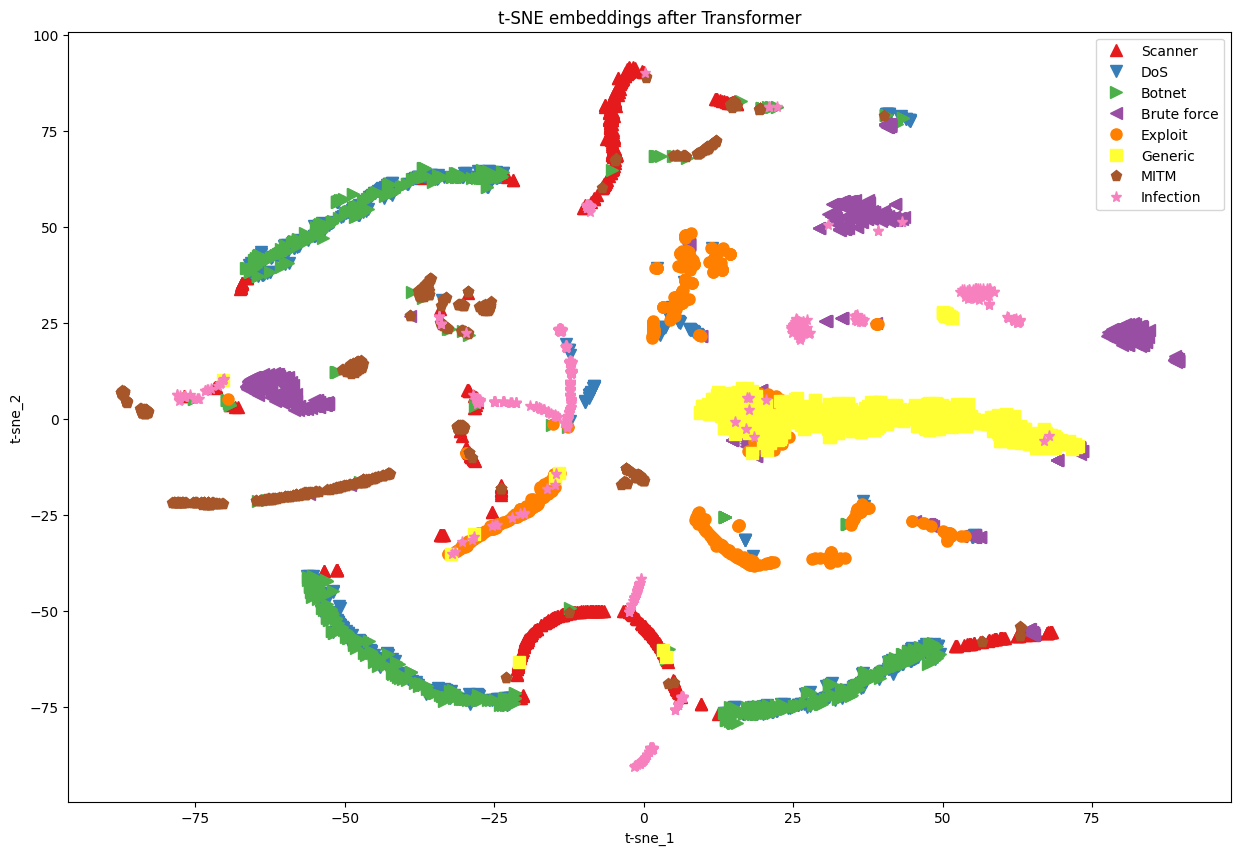

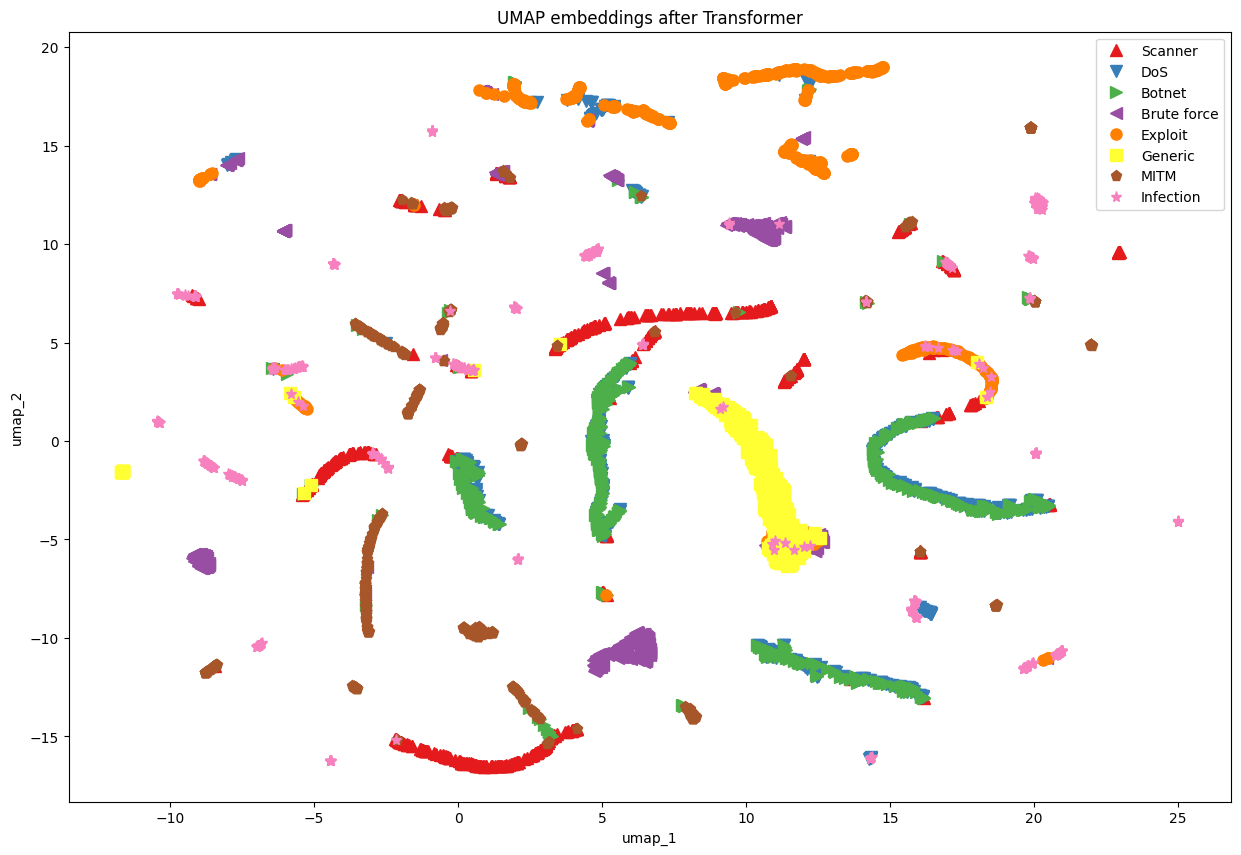

In [7]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 64), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(transformer_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

**Network specific features removed separatively**

KL divergence: -0.45482897758483887


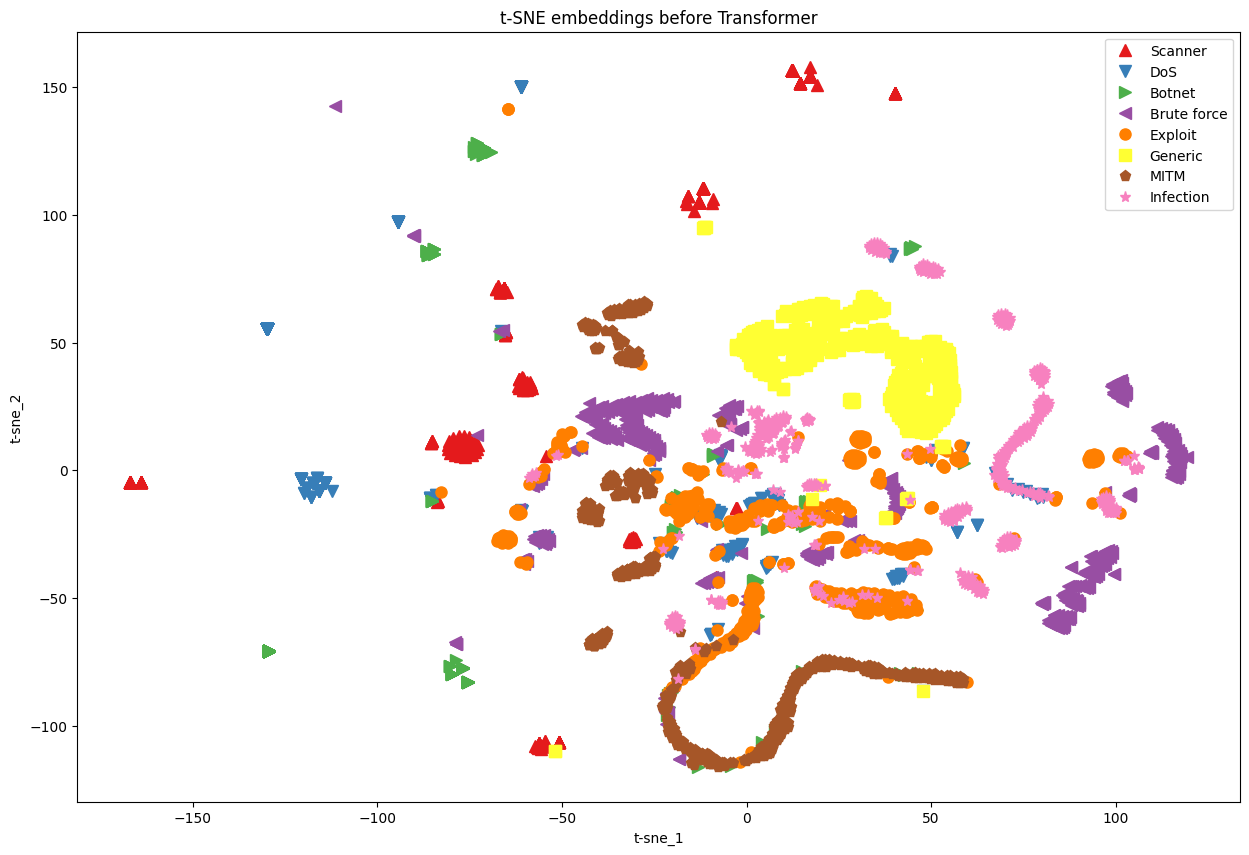

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


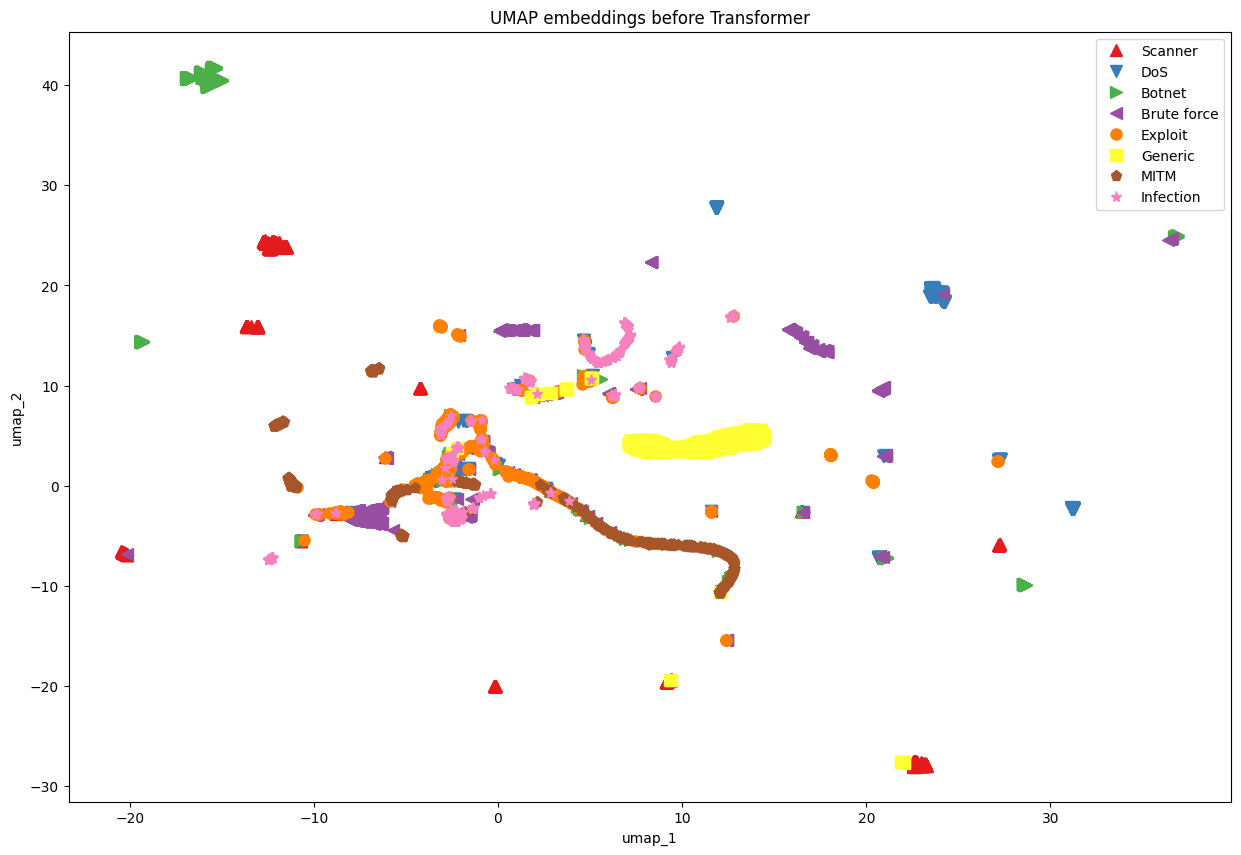

In [8]:
tsne_reducer = TSNE(n_components=2, perplexity=25, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_sep_removed_data.dataset[test_sep_removed_data.indices][0], test_sep_removed_data.dataset[test_sep_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")

76
KL divergence: 0.07493752241134644


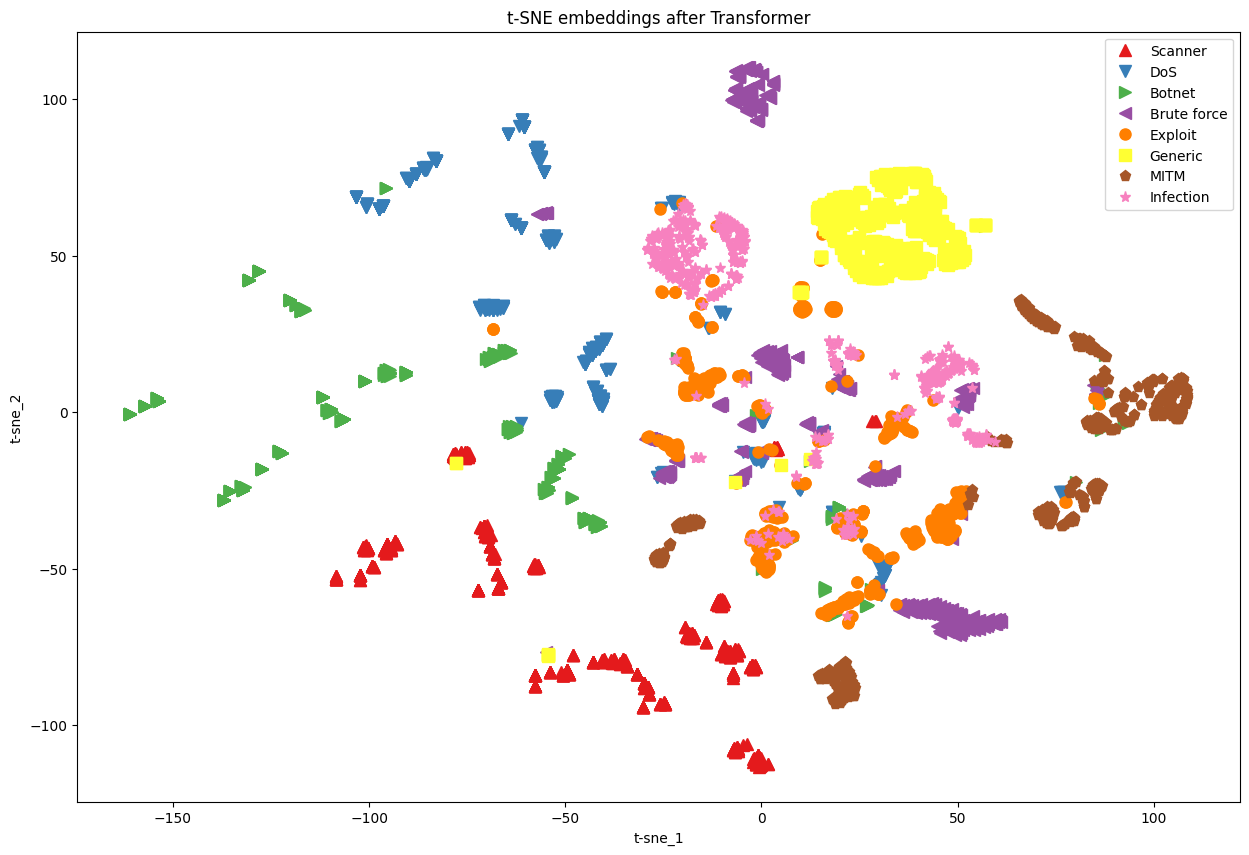

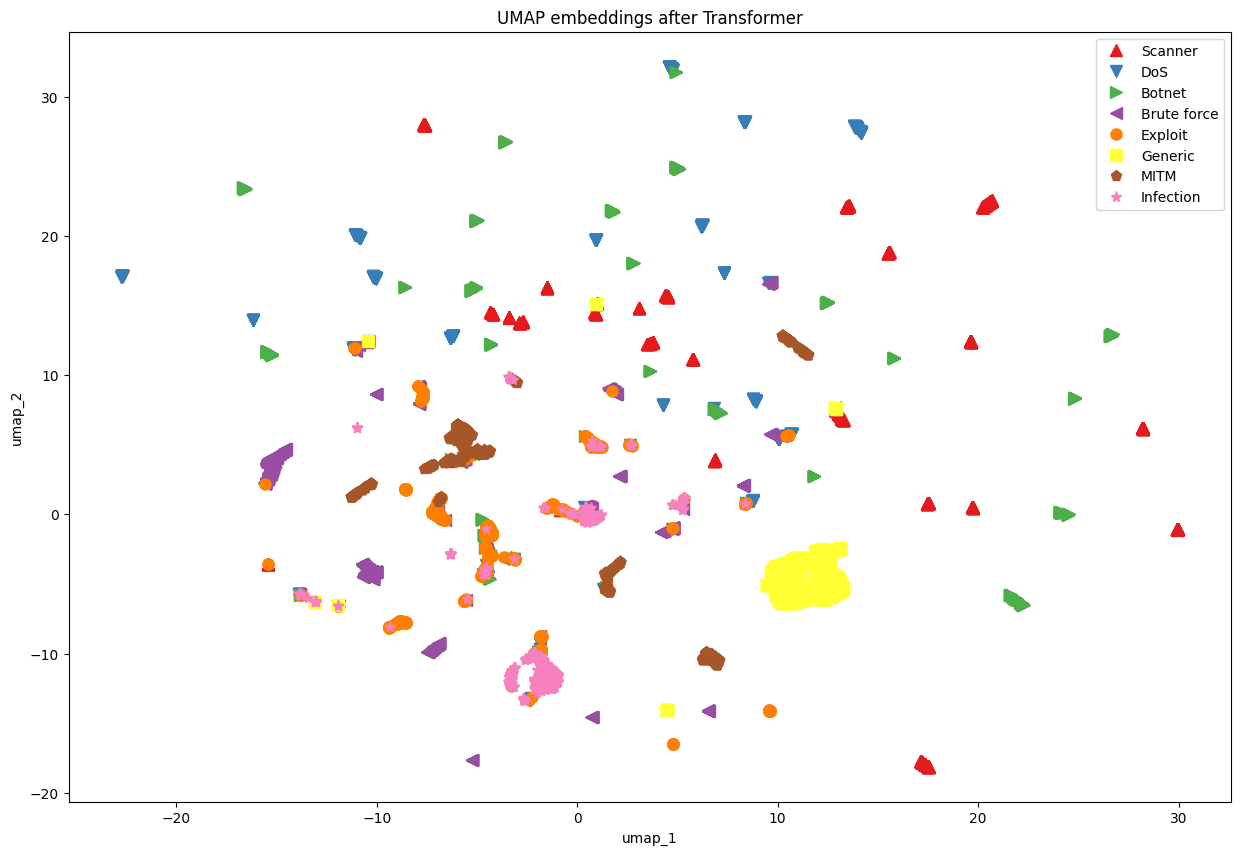

In [9]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_sep_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_sep_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=20, n_jobs=-1, min_dist=0.1)
embedding = umap_reducer.fit_transform(transformer_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

**Unified removed network-specific features**

KL divergence: -0.33056527376174927


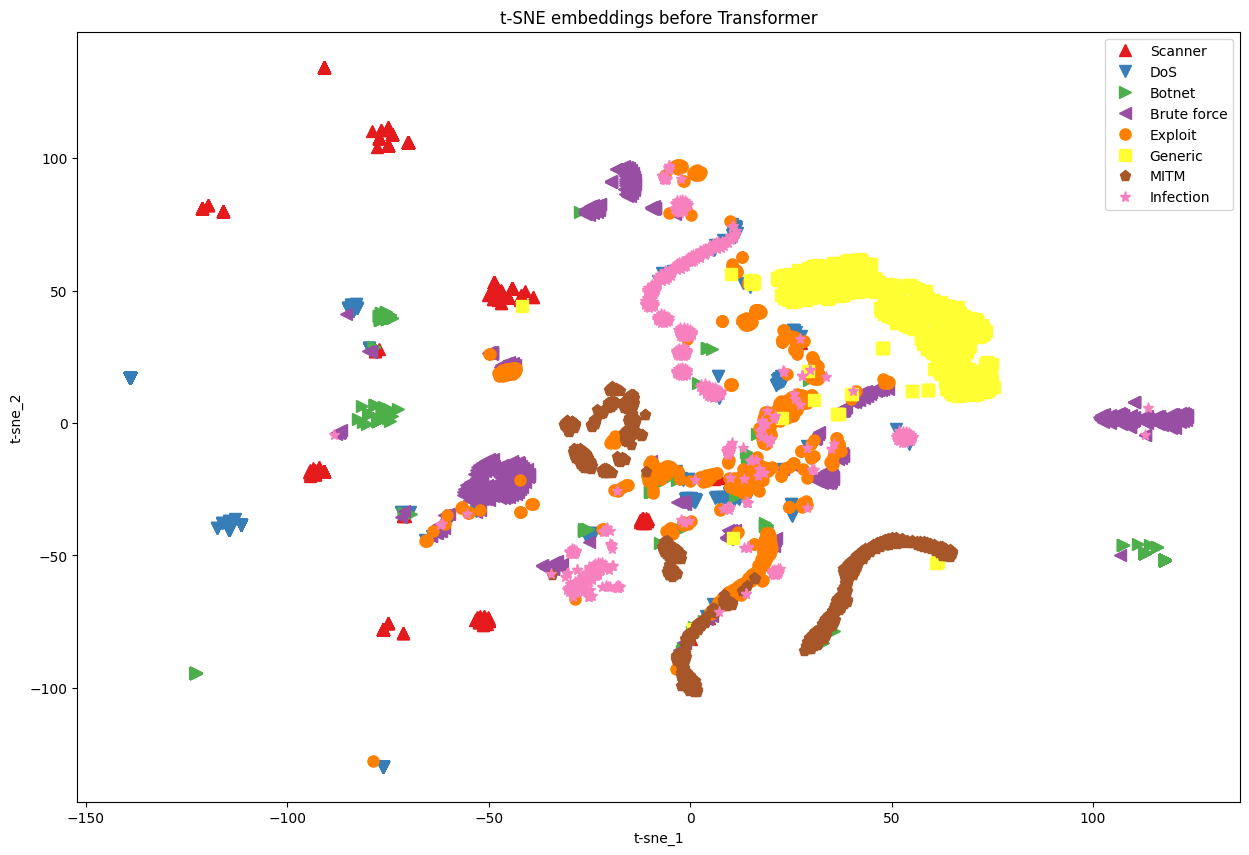

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


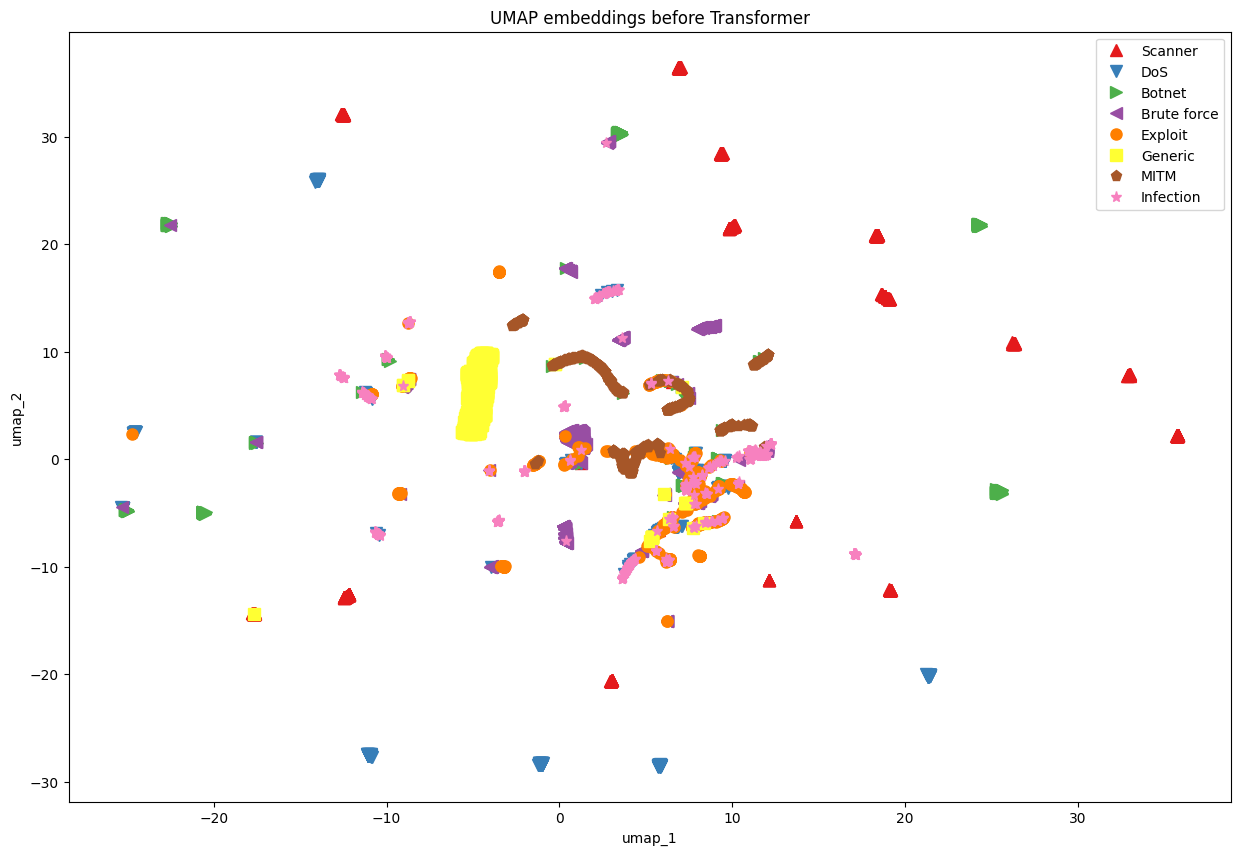

In [10]:
tsne_reducer = TSNE(n_components=2, perplexity=35, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_uni_removed_data.dataset[test_uni_removed_data.indices][0], test_uni_removed_data.dataset[test_uni_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")

74


KL divergence: 0.1263791173696518


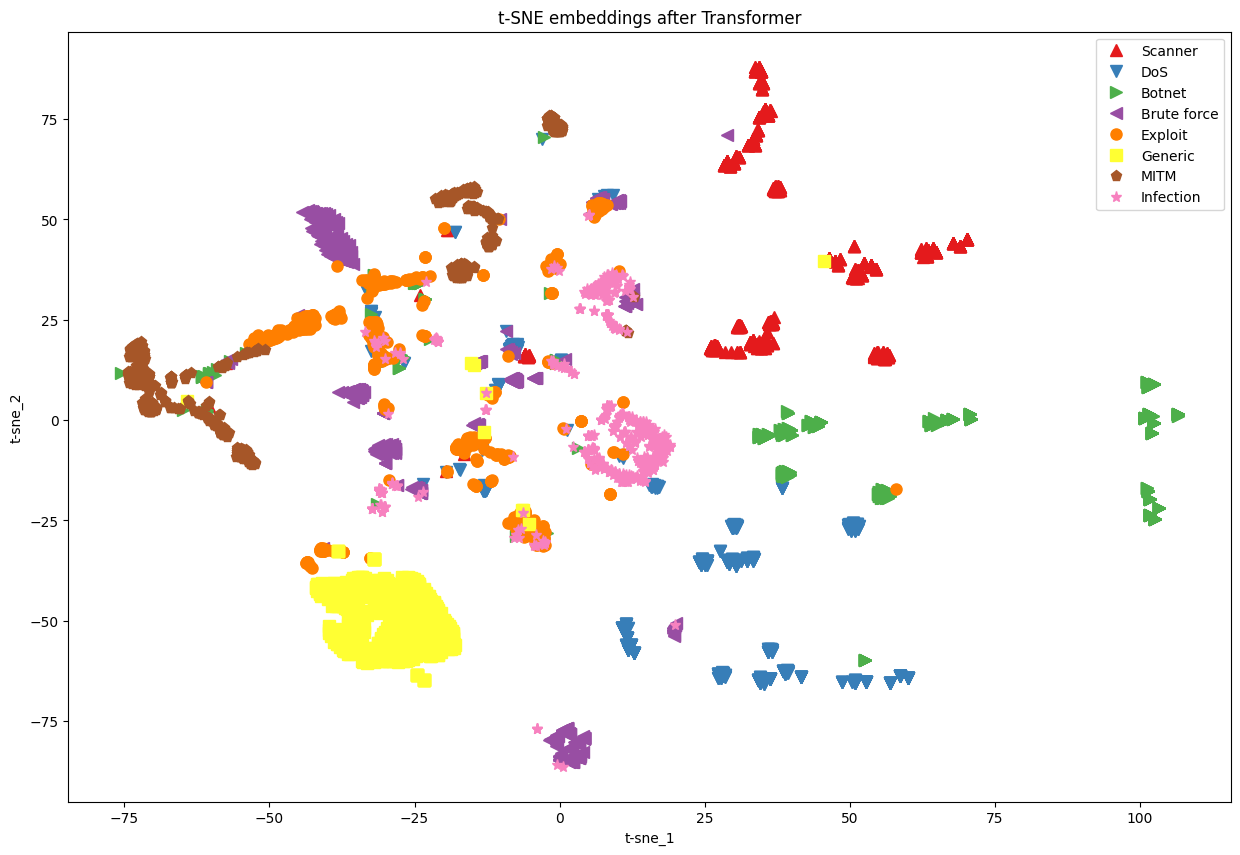

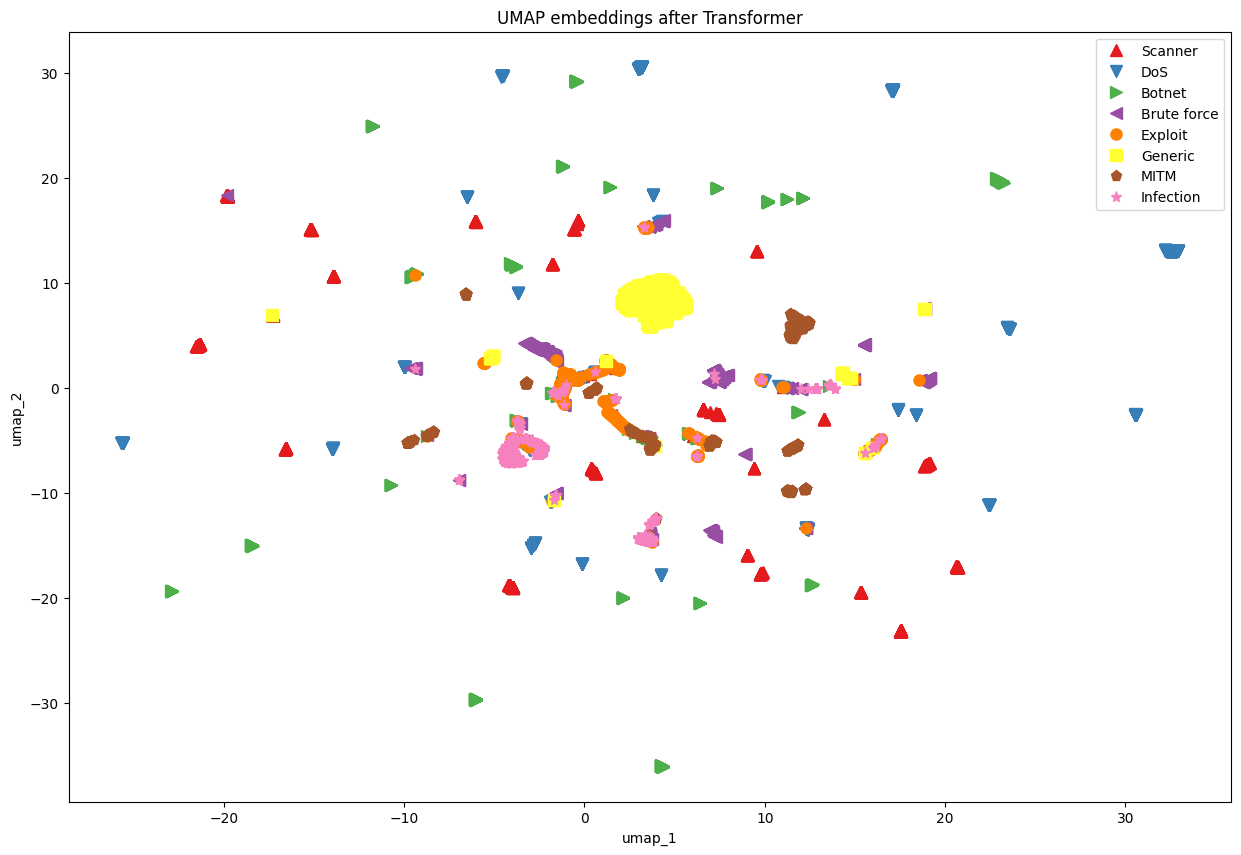

In [11]:
tsne_reducer = TSNE(n_components=2, perplexity=50, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_uni_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_uni_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.12)
embedding = umap_reducer.fit_transform(transformer_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

#### LSTM

**LSTM model hyperparameter loading and training**


In [12]:
lstm_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_lstm", "best_config_multiclass.json")
config = load_config(lstm_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
lstm_hyperparameters = config
lstm_hidden_states = config["hidden_lstm_states"]
lstm_model = MyLSTMClassifier(n_classes, **lstm_hyperparameters)

lstm_uni_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_lstm", "improved_removed_features_best_config.json")
config = load_config(lstm_uni_removed_config_file)
learning_uni_removed_rate = config.pop("lr")
batch_uni_removed_size = config.pop("batch_size")
lstm_uni_removed_hyperparameters = config
hidden_lstm_states_uni_removed = config["hidden_lstm_states"]

lstm_sep_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_lstm", "removed_features_best_config_multiclass.json")
config = load_config(lstm_sep_removed_config_file)
learning_sep_removed_rate = config.pop("lr")
batch_sep_removed_size = config.pop("batch_size")
lstm_sep_removed_hyperparameters = config
hidden_lstm_states_sep_removed = config["hidden_lstm_states"]

lstm_sep_removed_model = MyLSTMClassifier(n_classes, **lstm_sep_removed_hyperparameters)
lstm_uni_removed_model = MyLSTMClassifier(n_classes, **lstm_uni_removed_hyperparameters)

# training transformer with all network specific features included
print("TRAINING LSTM WITH ALL NETWORK SPECIFIC FEATURES!")
train_data, test_data = random_split(dataset, [0.965, 0.035])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_model.to(DEVICE)
ttutils.train_model(lstm_model, lstm_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=LSTM_EPOCHS)
del lstm_model

#training transformer with unified removed network specific 
print("TRAINING LSTM WITH UNIFIED REMOVED NETWORK SPECIFIC FEATURES!")
train_uni_removed_data, test_uni_removed_data = random_split(dataset_unified_removed, [0.965, 0.035])
train_loader = DataLoader(train_uni_removed_data, batch_uni_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_uni_removed_model.to(DEVICE)
ttutils.train_model(lstm_uni_removed_model, lstm_removed_uni_model_file, train_loader, None, metric=train_metric, 
                   learning_rate=learning_uni_removed_rate, epochs=LSTM_EPOCHS)
del lstm_uni_removed_model

#training transformer with all network specific features included
print("TRAINING LSTM WITH SEPARATE REMOVED NETWORK SPECIFIC FEATURES!")
train_sep_removed_data, test_sep_removed_data = random_split(dataset_lstm_removed, [0.965, 0.035])
train_loader = DataLoader(train_sep_removed_data, batch_sep_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_sep_removed_model.to(DEVICE)
ttutils.train_model(lstm_sep_removed_model, lstm_removed_sep_model_file, train_loader, None, metric=train_metric, 
                   learning_rate=learning_sep_removed_rate, epochs=LSTM_EPOCHS)
del lstm_sep_removed_model

TRAINING LSTM WITH ALL NETWORK SPECIFIC FEATURES!
Epoch 1/10. Average train accuracy: 57.459%, average loss: 0.97877, current loss: 0.56218.
Saved model!
Epoch 2/10. Average train accuracy: 72.096%, average loss: 0.59207, current loss: 0.50497.
Saved model!
Epoch 3/10. Average train accuracy: 75.806%, average loss: 0.51280, current loss: 1.10509.
Saved model!
Epoch 4/10. Average train accuracy: 79.192%, average loss: 0.44158, current loss: 0.49775.
Saved model!
Epoch 5/10. Average train accuracy: 79.728%, average loss: 0.41873, current loss: 0.16982.
Saved model!
Epoch 6/10. Average train accuracy: 80.154%, average loss: 0.40702, current loss: 0.00481.
Saved model!
Epoch 7/10. Average train accuracy: 80.376%, average loss: 0.39872, current loss: 0.00029.
Saved model!
Epoch 8/10. Average train accuracy: 80.668%, average loss: 0.38903, current loss: 0.94298.
Saved model!
Epoch 9/10. Average train accuracy: 80.761%, average loss: 0.38828, current loss: 0.47061.
Saved model!
Epoch 10/10. A

**With network specific features**

81
KL divergence: 0.370400071144104


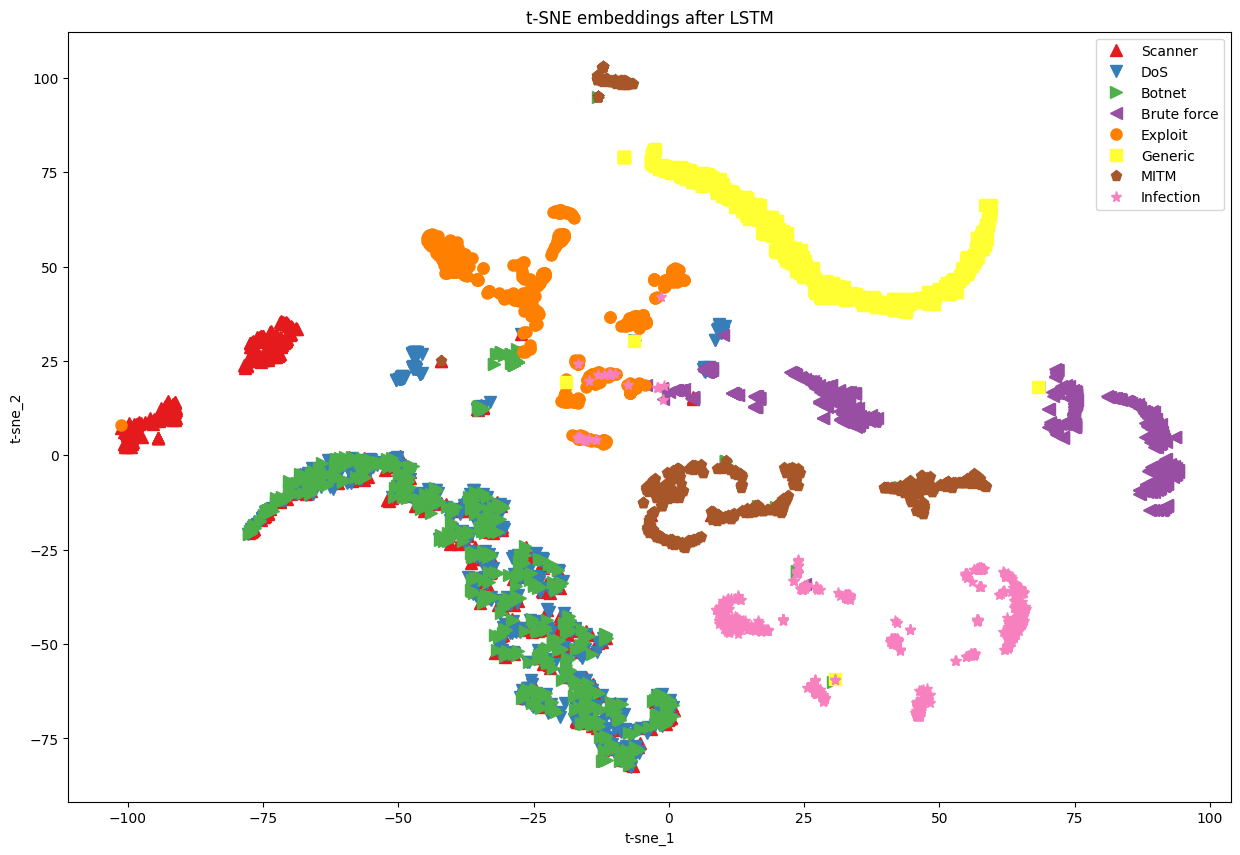

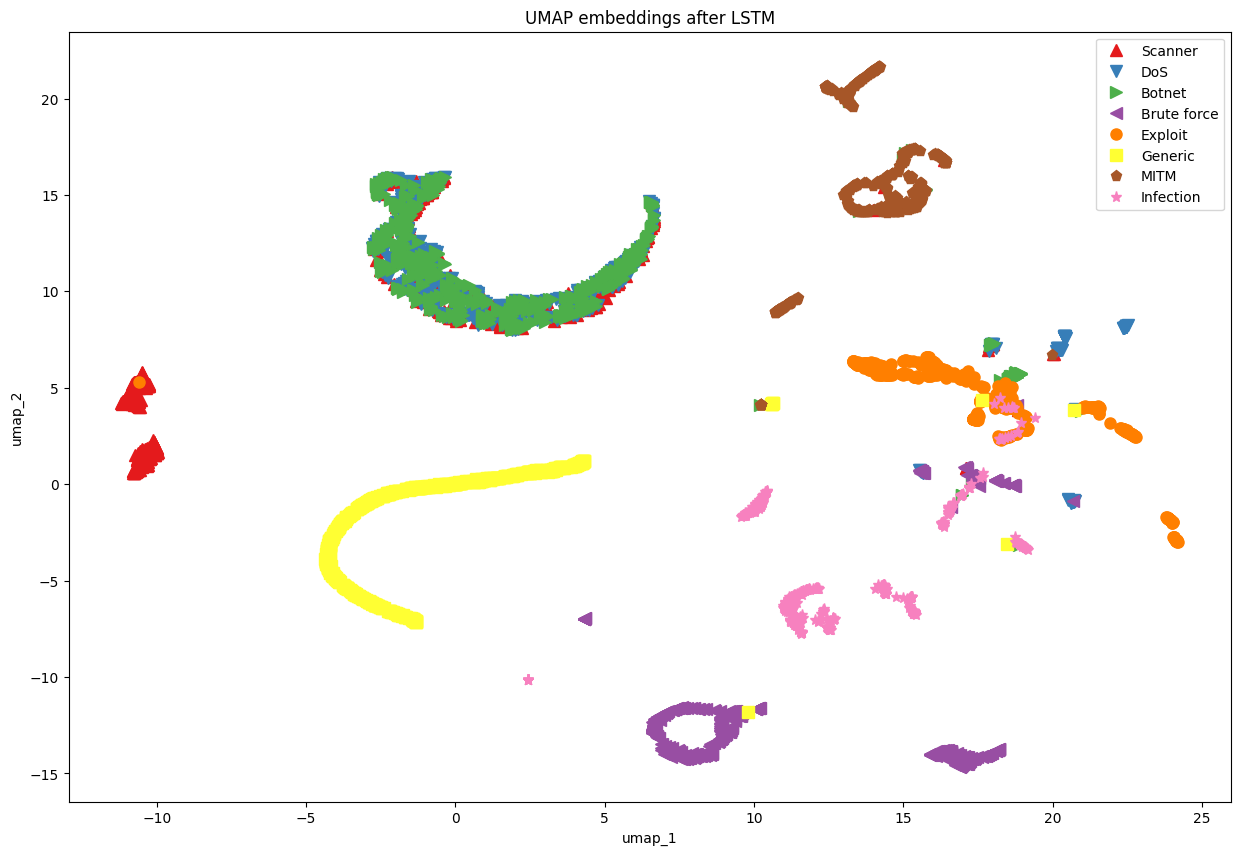

In [13]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
lstm_model = MyLSTMClassifier(n_classes, **lstm_hyperparameters).to(DEVICE)
lstm_model.load_state_dict(torch.load(lstm_model_file, weights_only=True))
lstm_model.eval()
lstm_output = torch.empty((X_test.shape[0], lstm_model.hidden_lstm_states//2), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        lstm_output[offset:offset+n] = lstm_model.lstm_layers(data)
        offset += n
assert offset == lstm_output.shape[0]

lstm_output = lstm_output.to("cpu")
embedding = tsne_reducer.fit_transform(lstm_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after LSTM")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=40, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(lstm_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after LSTM")

**Unified removed network-specific features**

74


KL divergence: 0.4787517786026001


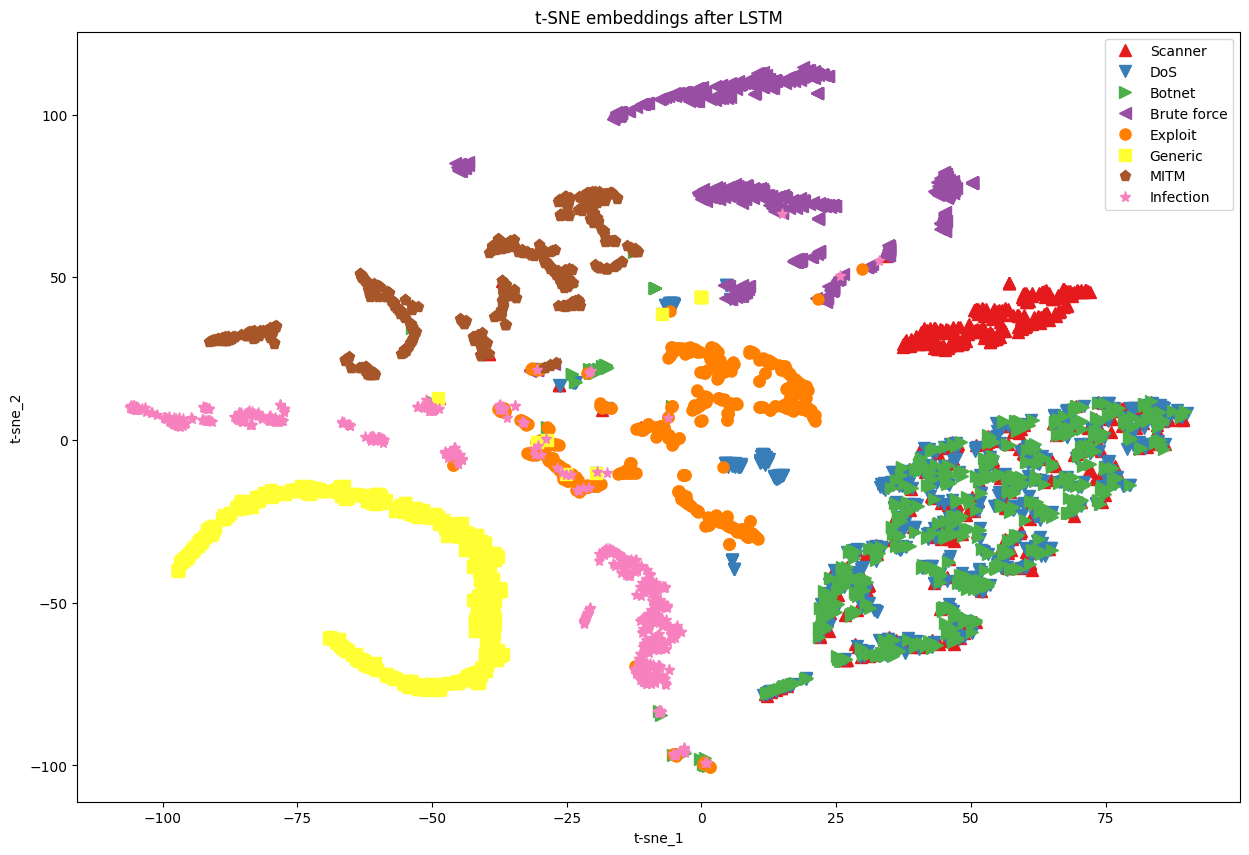

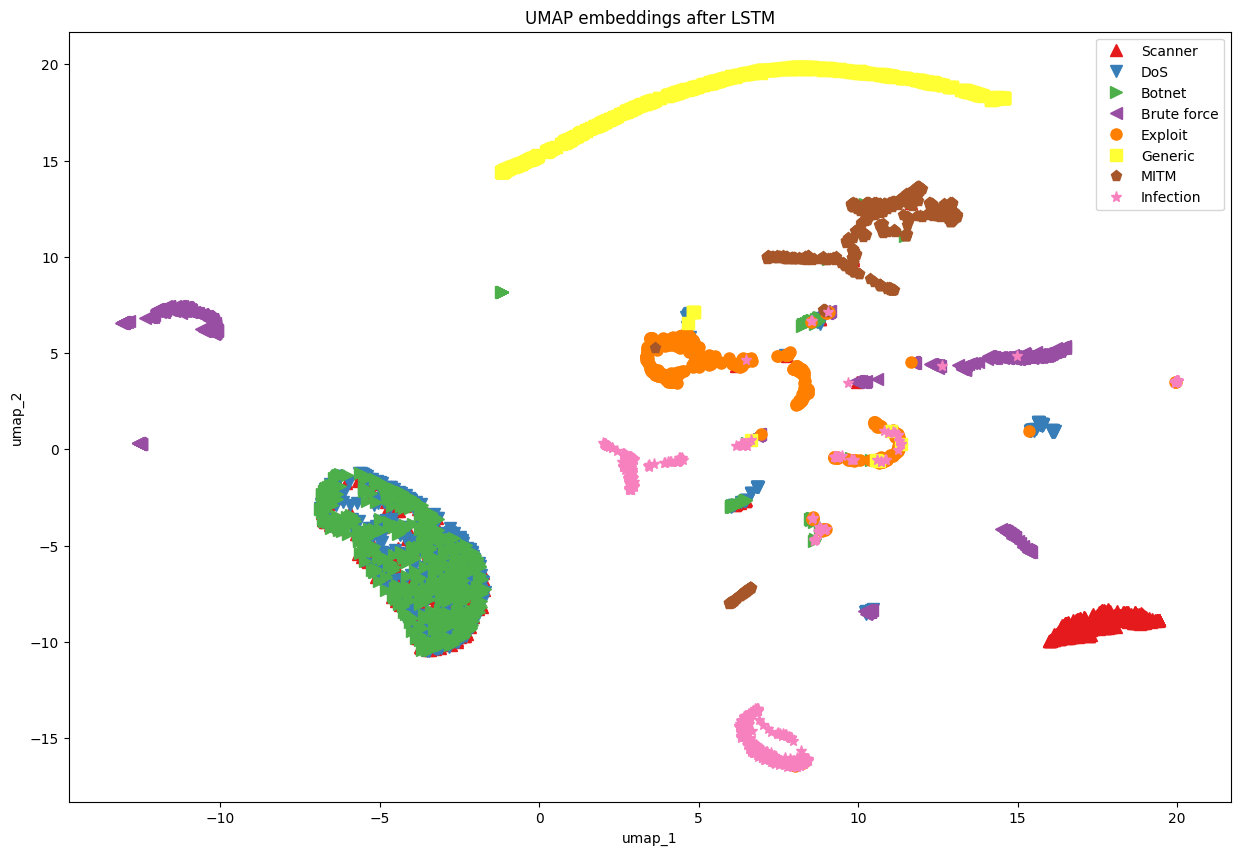

In [14]:
tsne_reducer = TSNE(n_components=2, perplexity=20, method="barnes_hut", n_jobs=-1, max_iter=2000)
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
X_test, y_test = test_uni_removed_data.dataset[test_uni_removed_data.indices][0], test_uni_removed_data.dataset[test_uni_removed_data.indices][1]
lstm_model = MyLSTMClassifier(n_classes, **lstm_uni_removed_hyperparameters).to(DEVICE)
lstm_model.load_state_dict(torch.load(lstm_removed_uni_model_file, weights_only=True))
lstm_model.eval()
lstm_output = torch.empty((X_test.shape[0], lstm_model.hidden_lstm_states//2), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_uni_removed_data, batch_size=batch_uni_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        lstm_output[offset:offset+n] = lstm_model.lstm_layers(data)
        offset += n
assert offset == lstm_output.shape[0]

lstm_output = lstm_output.to("cpu")
embedding = tsne_reducer.fit_transform(lstm_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after LSTM")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=40, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(lstm_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after LSTM")

**Separate removed network-specific features**

80
KL divergence: 0.364611953496933


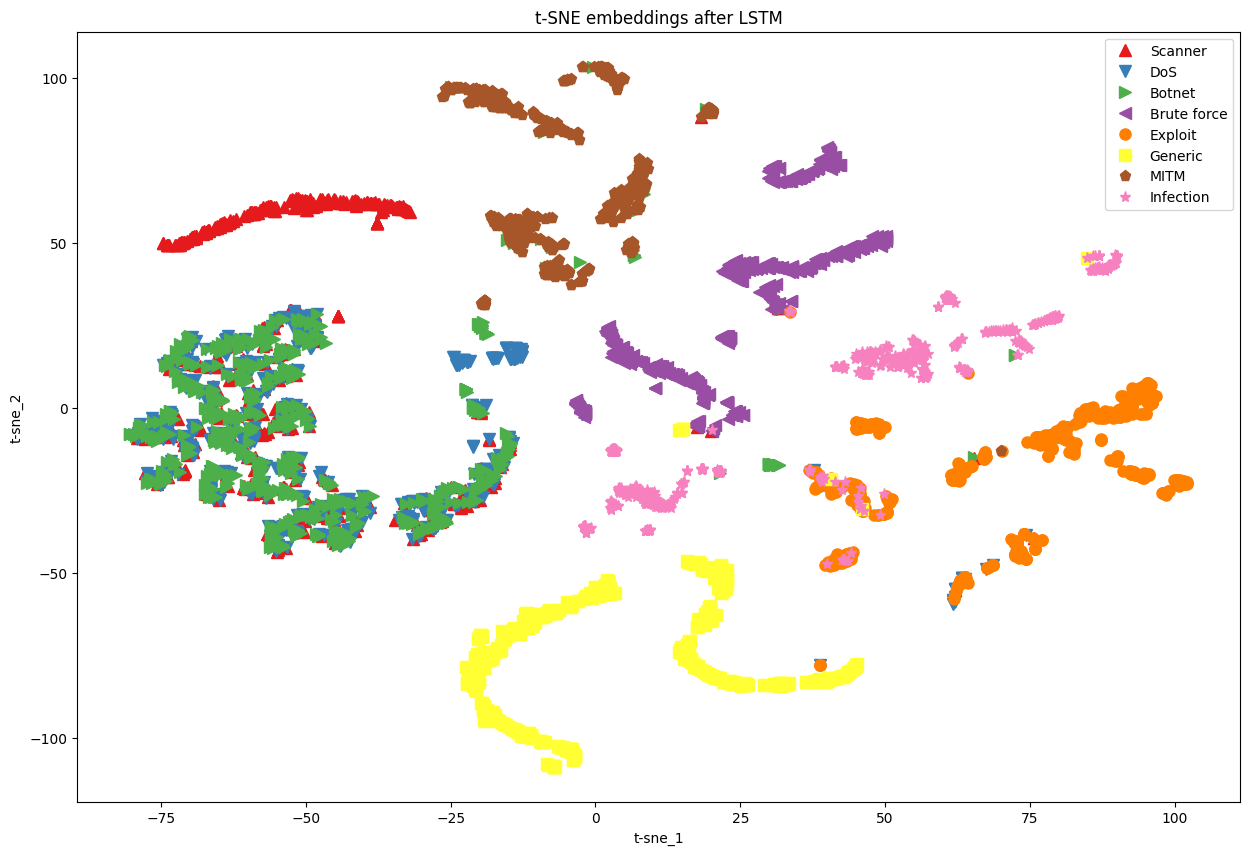

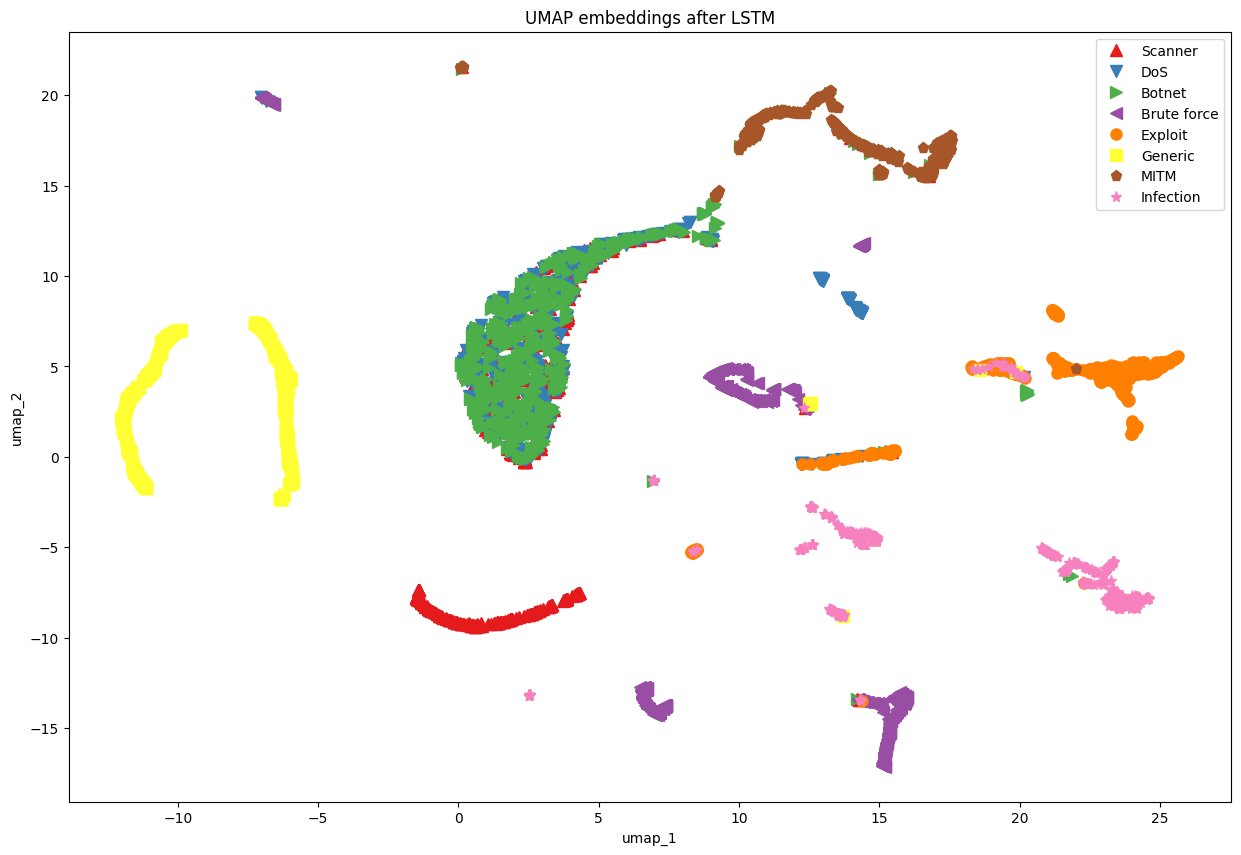

In [15]:
tsne_reducer = TSNE(n_components=2, perplexity=25, method="barnes_hut", n_jobs=-1, max_iter=2000)
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
X_test, y_test = test_sep_removed_data.dataset[test_sep_removed_data.indices][0], test_sep_removed_data.dataset[test_sep_removed_data.indices][1]
lstm_model = MyLSTMClassifier(n_classes, **lstm_sep_removed_hyperparameters).to(DEVICE)
lstm_model.load_state_dict(torch.load(lstm_removed_sep_model_file, weights_only=True))
lstm_model.eval()
lstm_output = torch.empty((X_test.shape[0], lstm_model.hidden_lstm_states//2), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_sep_removed_data, batch_size=batch_sep_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        lstm_output[offset:offset+n] = lstm_model.lstm_layers(data)
        offset += n
assert offset == lstm_output.shape[0]

lstm_output = lstm_output.to("cpu")
embedding = tsne_reducer.fit_transform(lstm_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after LSTM")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(lstm_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after LSTM")

#### CNN
**CNN model hyperparameters loading and training**

In [25]:
cnn_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_cnn", "best_config_multiclass.json")
config = load_config(cnn_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
cnn_hyperparameters = config
cnn_model = MyCNNModel(n_classes, **cnn_hyperparameters)

cnn_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_cnn", "removed_features_best_config_multiclass.json")
config = load_config(cnn_removed_config_file)
learning_sep_removed_rate = config.pop("lr")
batch_removed_size = config.pop("batch_size")
cnn_removed_hyperparameters = config
cnn_sep_removed_model = MyCNNModel(n_classes, **cnn_removed_hyperparameters)

# training transformer with all network specific features included
train_data, test_data = random_split(dataset, [0.965, 0.035])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, num_workers=8, prefetch_factor=4)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
cnn_model.to(DEVICE)
print(dataset.tensors[0].shape, dataset_cnn_removed.tensors[0].shape)
print("TRAINING CNN MODEL WITH ALL NETWORK SPECIFIC FEATURES INCLUDED!")
ttutils.train_model(cnn_model, cnn_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=CNN_EPOCHS)
del cnn_model

# training transformer with all network specific features included
print("TRAINING CNN WITH SEPARATE REMOVED NETWORK SPECIFIC FEATURES!")
train_sep_removed_data, test_sep_removed_data = random_split(dataset_cnn_removed, [0.965, 0.035])
train_loader = DataLoader(train_sep_removed_data, batch_removed_size, shuffle=True, pin_memory=True, num_workers=8, prefetch_factor=4)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
cnn_sep_removed_model.to(DEVICE)
ttutils.train_model(cnn_sep_removed_model, cnn_sep_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_sep_removed_rate, epochs=CNN_EPOCHS)
del cnn_sep_removed_model

torch.Size([134136, 81]) torch.Size([134136, 75])
TRAINING CNN MODEL WITH ALL NETWORK SPECIFIC FEATURES INCLUDED!
Epoch 1/40. Average train accuracy: 40.533%, average loss: 1.42112, current loss: 1.22147.
Saved model!
Epoch 2/40. Average train accuracy: 49.998%, average loss: 1.19863, current loss: 1.09578.
Saved model!


Exception ignored in: <function _afterFork at 0x7f0a556bdf80>
Traceback (most recent call last):
  File "/home/sbaltsas/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/logging/__init__.py", line 245, in _afterFork
    def _afterFork():
KeyboardInterrupt: 


Epoch 3/40. Average train accuracy: 51.178%, average loss: 1.15129, current loss: 1.13803.
Saved model!
Epoch 4/40. Average train accuracy: 52.242%, average loss: 1.12707, current loss: 1.07557.
Saved model!
Epoch 5/40. Average train accuracy: 52.703%, average loss: 1.11399, current loss: 1.07931.
Saved model!
Epoch 6/40. Average train accuracy: 54.084%, average loss: 1.10054, current loss: 1.17710.
Saved model!
Epoch 7/40. Average train accuracy: 55.643%, average loss: 1.08557, current loss: 1.07804.
Saved model!
Epoch 8/40. Average train accuracy: 56.797%, average loss: 1.06926, current loss: 1.12357.
Saved model!
Epoch 9/40. Average train accuracy: 57.425%, average loss: 1.05616, current loss: 1.06633.
Saved model!
Epoch 10/40. Average train accuracy: 57.798%, average loss: 1.04982, current loss: 1.01989.
Saved model!
Epoch 11/40. Average train accuracy: 58.147%, average loss: 1.03809, current loss: 0.93208.
Saved model!
Epoch 12/40. Average train accuracy: 58.341%, average loss: 1.

Exception ignored in: <function _afterFork at 0x7f0a556bdf80>
Traceback (most recent call last):
  File "/home/sbaltsas/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/lib/python3.13/logging/__init__.py", line 245, in _afterFork
    def _afterFork():
KeyboardInterrupt: 


Epoch 13/40. Average train accuracy: 59.140%, average loss: 1.01718, current loss: 1.02469.
Saved model!
Epoch 14/40. Average train accuracy: 59.431%, average loss: 1.01349, current loss: 0.99479.
Saved model!
Epoch 15/40. Average train accuracy: 59.811%, average loss: 1.00310, current loss: 0.96801.
Saved model!
Epoch 16/40. Average train accuracy: 59.877%, average loss: 1.00158, current loss: 1.18312.
Saved model!
Epoch 17/40. Average train accuracy: 58.321%, average loss: 1.02843, current loss: 0.92917.
Epoch 18/40. Average train accuracy: 59.114%, average loss: 1.02054, current loss: 1.10604.
Epoch 19/40. Average train accuracy: 59.273%, average loss: 1.02022, current loss: 0.98495.
Epoch 20/40. Average train accuracy: 59.650%, average loss: 1.01633, current loss: 0.98069.
Epoch 21/40. Average train accuracy: 59.592%, average loss: 1.01173, current loss: 1.05801.
Epoch 22/40. Average train accuracy: 60.230%, average loss: 1.00544, current loss: 0.92892.
Epoch 23/40. Average train a

**With network specific features**

81
KL divergence: -0.42049404978752136


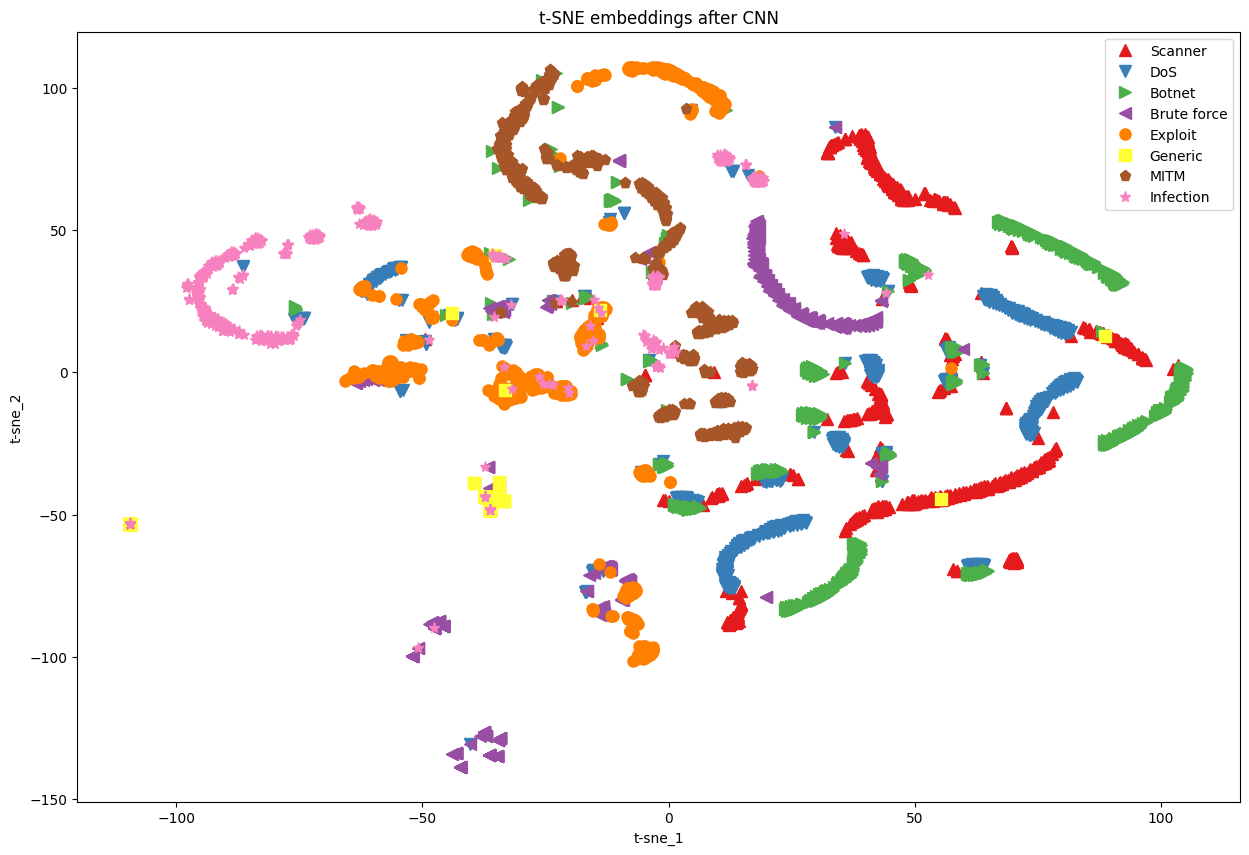

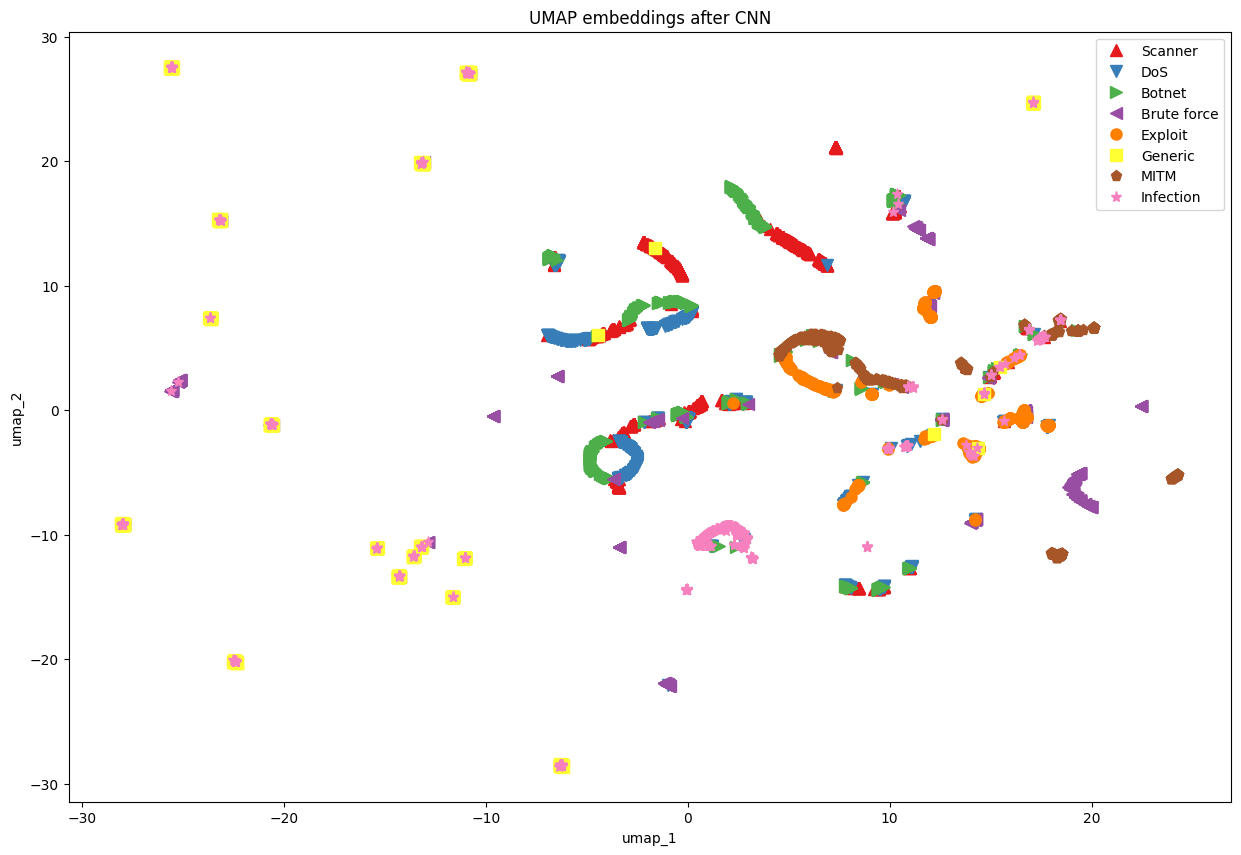

In [26]:
tsne_reducer = TSNE(n_components=2, perplexity=25, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
cnn_model = MyCNNModel(n_classes, **cnn_hyperparameters).to(DEVICE)
cnn_model.load_state_dict(torch.load(cnn_model_file, weights_only=True))
cnn_model.eval()
cnn_output = torch.empty((X_test.shape[0], 57), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False, prefetch_factor=4)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        data = data.unsqueeze(1).to(DEVICE)
        n = data.shape[0]
        cnn_output[offset:offset+n] = cnn_model.cnn_model(data).flatten(1)
        offset += n
assert offset == cnn_output.shape[0]

cnn_output = cnn_output.to("cpu")
embedding = tsne_reducer.fit_transform(cnn_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after CNN")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.1)
embedding = umap_reducer.fit_transform(cnn_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after CNN")

**Separate removed features**

75
KL divergence: 0.07481114566326141


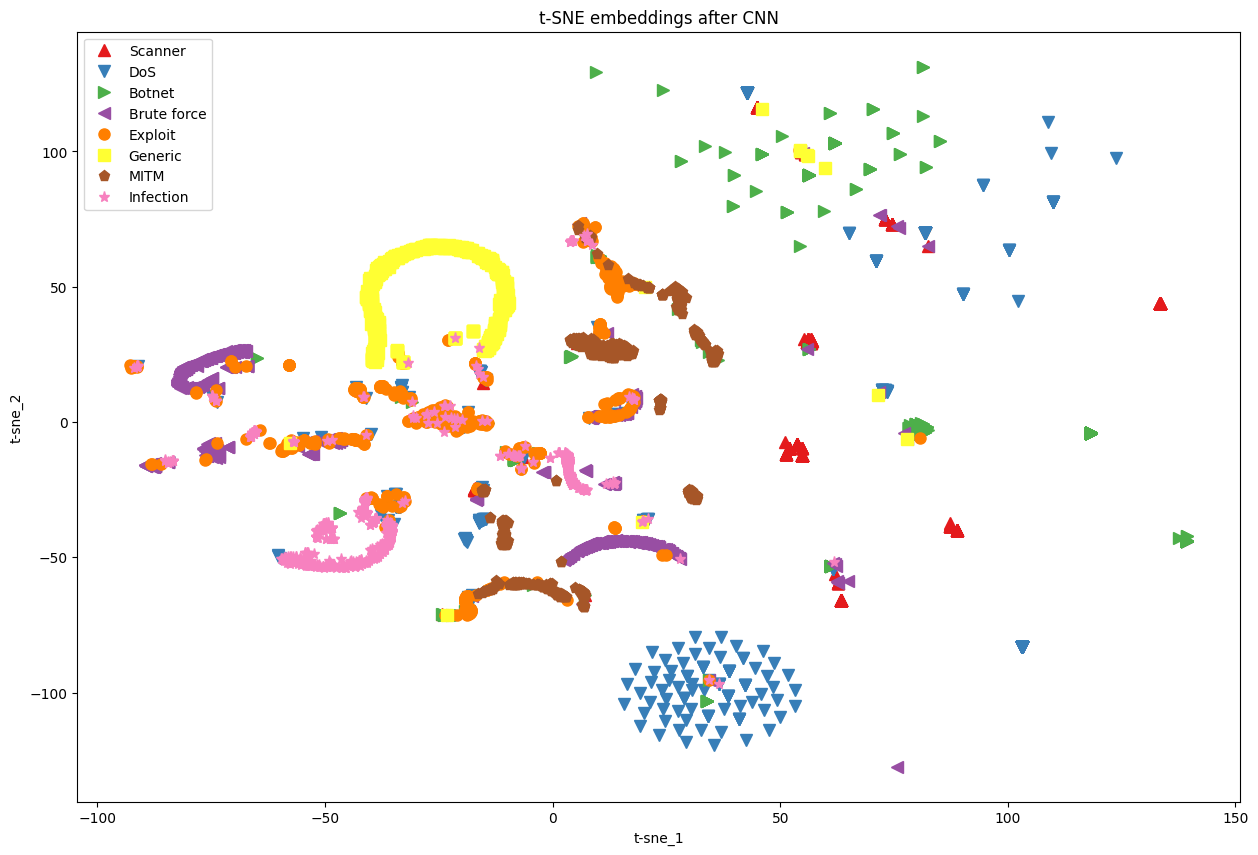

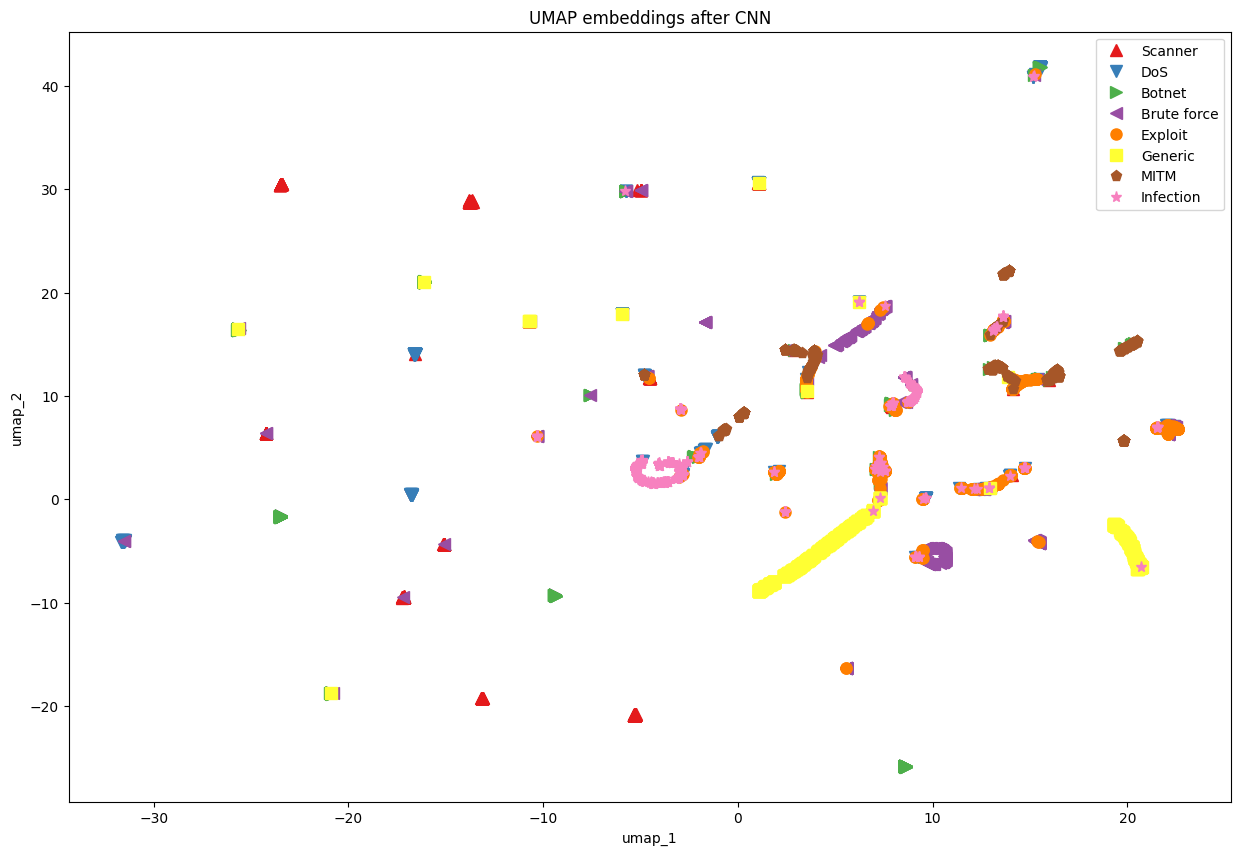

In [29]:
tsne_reducer = TSNE(n_components=2, perplexity=35, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_sep_removed_data.dataset[test_sep_removed_data.indices][0], test_sep_removed_data.dataset[test_sep_removed_data.indices][1]
cnn_model = MyCNNModel(n_classes, **cnn_removed_hyperparameters).to(DEVICE)
cnn_model.load_state_dict(torch.load(cnn_sep_removed_model_file, weights_only=True))
cnn_model.eval()
cnn_output = torch.empty((X_test.shape[0], 68), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_sep_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False, prefetch_factor=4)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        data = data.unsqueeze(1).to(DEVICE)
        n = data.shape[0]
        cnn_output[offset:offset+n] = cnn_model.cnn_model(data).flatten(1)
        offset += n
assert offset == cnn_output.shape[0]

cnn_output = cnn_output.to("cpu")
embedding = tsne_reducer.fit_transform(cnn_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after CNN")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.01)
embedding = umap_reducer.fit_transform(cnn_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after CNN")